<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L08-Volatilidad/notebooks/L08_2_ModeloGARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install arch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

In [2]:
# Subir archivo sp500
from google.colab import files
files.upload()

Saving sp500.csv to sp500 (5).csv


{'sp500 (5).csv': b'"Date","Return"\r\n1990-01-02,-0.258890812009049\r\n1990-01-03,-0.865030658884791\r\n1990-01-04,-0.980413859884877\r\n1990-01-05,0.45043207078832\r\n1990-01-08,-1.18566663869508\r\n1990-01-09,-0.662909749729135\r\n1990-01-10,0.350655682365808\r\n1990-01-11,-2.49845956488199\r\n1990-01-12,-0.865678370822298\r\n1990-01-15,1.10661402242806\r\n1990-01-16,-0.987990046477449\r\n1990-01-17,0.233869761268224\r\n1990-01-18,0.283461966753862\r\n1990-01-19,-2.61989802650939\r\n1990-01-22,0.371607249487838\r\n1990-01-23,-0.407935658703096\r\n1990-01-24,-1.27374730004819\r\n1990-01-25,-0.0859053866415493\r\n1990-01-26,-0.184331849428876\r\n1990-01-29,-0.684997587273539\r\n1990-01-30,1.87104804998093\r\n1990-01-31,-0.0881633206512689\r\n1990-02-01,0.645740522776528\r\n1990-02-02,0.280640526995146\r\n1990-02-05,-0.662123928872393\r\n1990-02-06,1.23303894112494\r\n1990-02-07,-0.236984706913468\r\n1990-02-08,0.1980258080585\r\n1990-02-09,-1.06675714029683\r\n1990-02-12,0.28437471894

In [3]:
df = pd.read_csv('/content/sp500.csv')
df.head()

,Date,Return
0,1990-01-02,-0.258891
1,1990-01-03,-0.865031
2,1990-01-04,-0.980414
3,1990-01-05,0.450432
4,1990-01-08,-1.185667


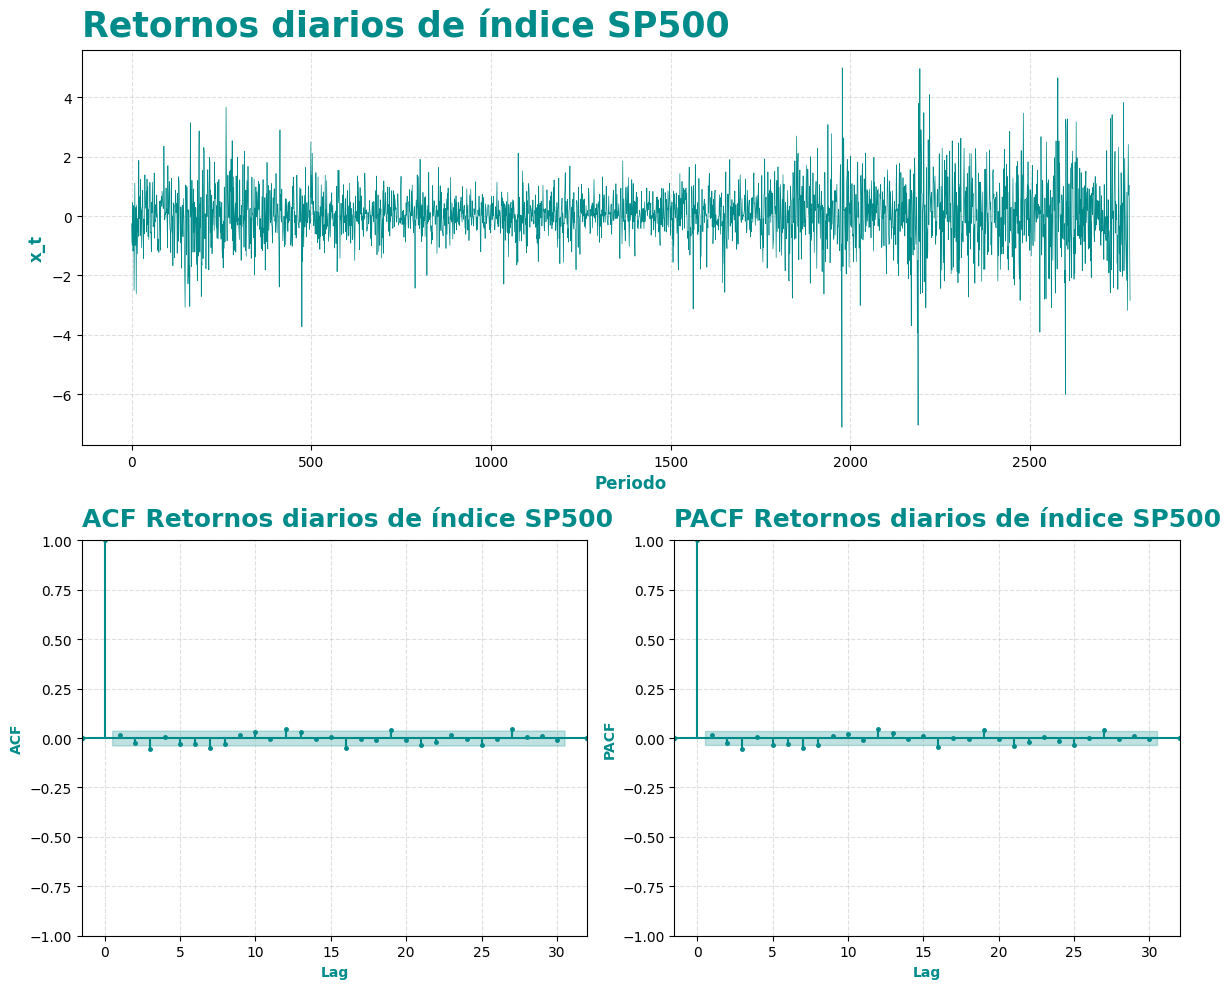

In [4]:
graphColor = 'darkcyan'
columna = 'Return'
nombre = 'Retornos diarios de índice SP500'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

In [5]:
df['Return_ajust'] = (df['Return'] - df['Return'].mean()) # OJO: porque para modelos GARCH es más conveniente regresar hacia la media
df['Return_ajust_sq'] = df['Return_ajust']**2
df.head()

,Date,Return,Return_ajust,Return_ajust_sq
0,1990-01-02,-0.258891,-0.304643,0.092808
1,1990-01-03,-0.865031,-0.910783,0.829526
2,1990-01-04,-0.980414,-1.026167,1.053018
3,1990-01-05,0.450432,0.404679,0.163765
4,1990-01-08,-1.185667,-1.231419,1.516394


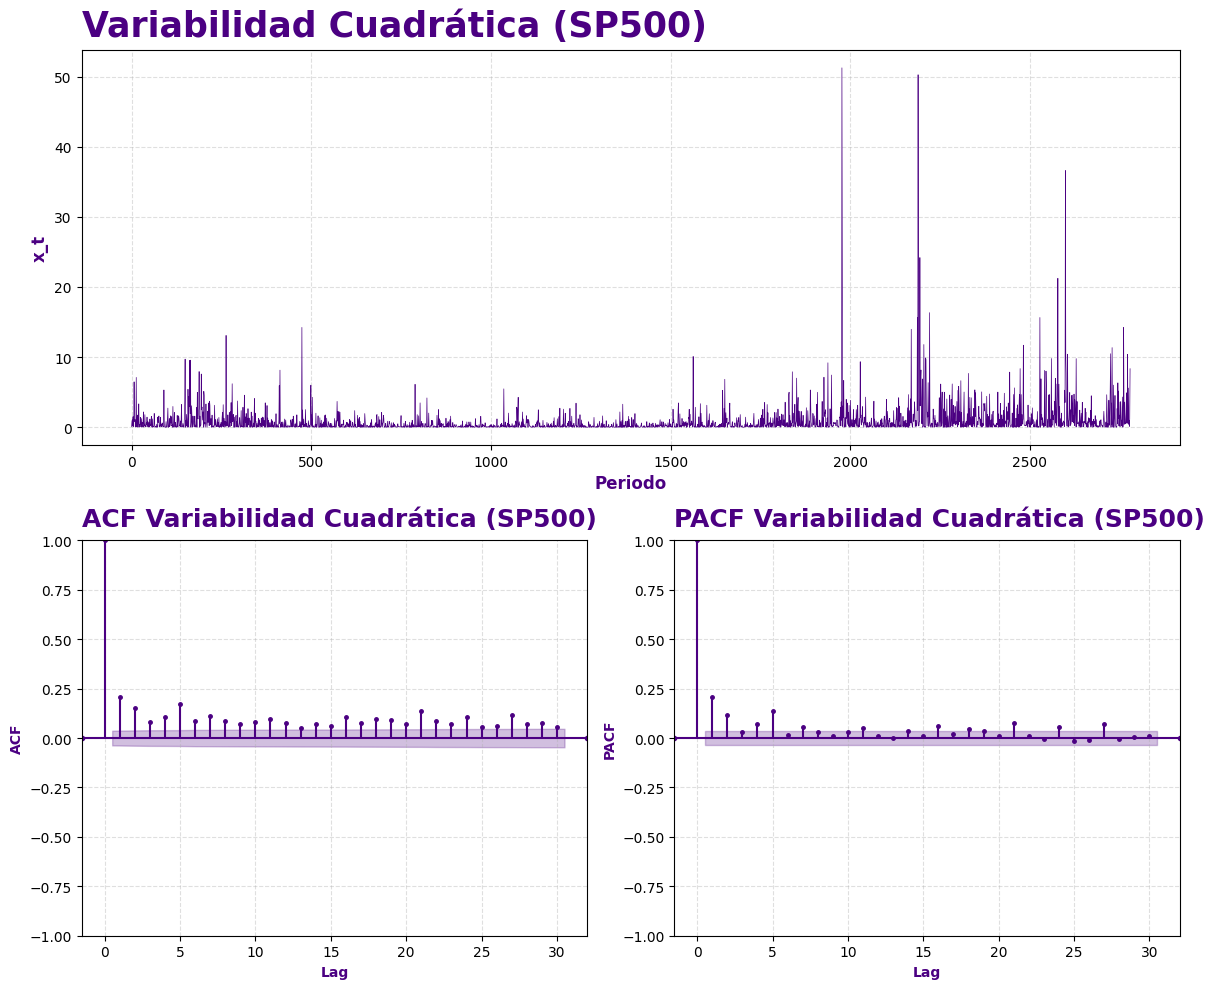

In [6]:
graphColor = 'indigo'
columna = 'Return_ajust_sq'
nombre = 'Variabilidad Cuadrática (SP500)'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

## **Modelo GARCH**

In [7]:
model_garch = arch_model(df['Return_ajust'], vol='GARCH', p=1, q=1)
model_fit = model_garch.fit(disp='off')
print(model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:           Return_ajust   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3479.97
Distribution:                  Normal   AIC:                           6967.94
Method:            Maximum Likelihood   BIC:                           6991.66
                                        No. Observations:                 2780
Date:                Sun, Jun 28 2026   Df Residuals:                     2779
Time:                        02:16:34   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         8.4815e-03  1.451e-02      0.585      0.559 

In [8]:
alpha0 = model_fit.params['omega']
alpha1 = model_fit.params['alpha[1]']
beta1 = model_fit.params['beta[1]']

In [9]:
# Inicializar columnas con ceros
df['h'] = 0.0
df['E'] = 0.0

# Valores iniciales para h y E
df.loc[0, 'h'] = alpha0 / (1 - alpha1 - beta1)
df.loc[0, 'E'] = np.sqrt(df.loc[0, 'h'])

for i in range(1, len(df)):
    # GARCH(1,1) formula fpara varianza condicional:
    # h[i] = alpha_0 + alpha_1 * E[i-1]^2 + beta1 * h[i-1]
    # epsilon_{t-1}^2 is df['Return_ajust_sq'] for the previous period
    df.loc[i, 'h'] = alpha0 + alpha1 * df.loc[i-1, 'Return_ajust_sq'] + beta1 * df.loc[i-1, 'h']

    # La volatilidad condicional es la raíz cuadrada de la varianza condicional
    df.loc[i, 'E'] = np.sqrt(df.loc[i, 'h'])

# Retornos ajustados divididos por la desviación estándar condicional estimada por el modelo
# Si el GARCH es adecuado, estos residuales deberían ser ruido blanco sin autocorrelación.
df['residual'] = df['Return'] / df['E']
# Calculemos residuales al cuadrado
df['residual_sq'] = df['residual']**2

df.head()

,Date,Return,Return_ajust,Return_ajust_sq,h,E,residual,residual_sq
0,1990-01-02,-0.258891,-0.304643,0.092808,1.330232,1.153357,-0.224467,0.050386
1,1990-01-03,-0.865031,-0.910783,0.829526,1.265160,1.124793,-0.769057,0.591449
2,1990-01-04,-0.980414,-1.026167,1.053018,1.242481,1.114666,-0.879558,0.773623
3,1990-01-05,0.450432,0.404679,0.163765,1.232827,1.110327,0.405675,0.164572
4,1990-01-08,-1.185667,-1.231419,1.516394,1.176951,1.084874,-1.092907,1.194446


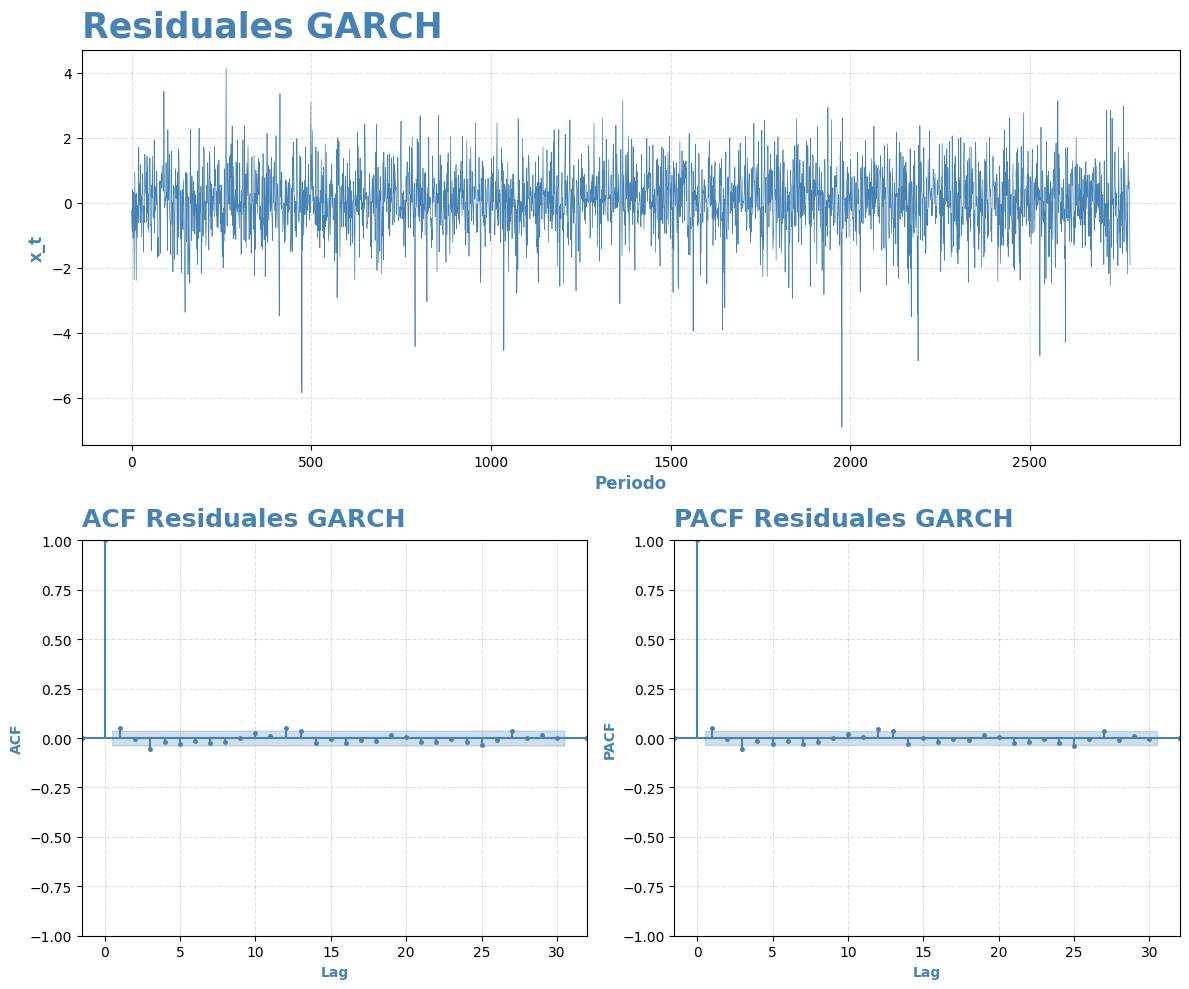

In [10]:
graphColor = 'steelblue'
columna = 'residual'
nombre = 'Residuales GARCH'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

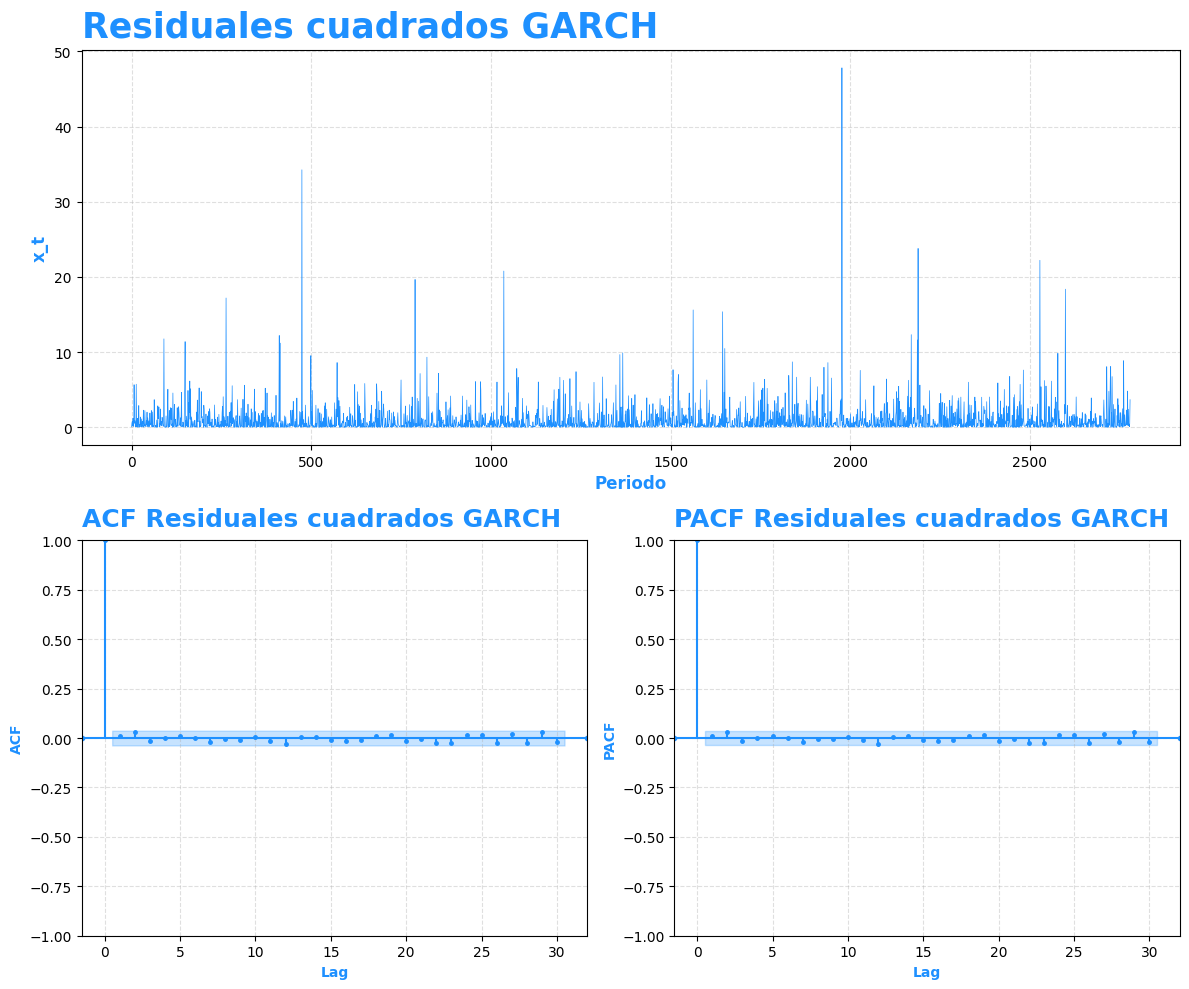

In [11]:
graphColor = 'dodgerblue'
columna = 'residual_sq'
nombre = 'Residuales cuadrados GARCH'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor, lw=.5)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()